In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze risk justification text and relationships
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from sklearn.cluster import KMeans

import networkx as nx
from textblob import TextBlob


# Load dataset

In [4]:
# Load dataset
p_df = pd.read_csv("data/proper/prop_conversations.csv", encoding='latin1')
o_df = pd.read_csv("data/open/open_conversations.csv", encoding='latin1')
p_df.columns

Index(['character', 'comment_number', 'topic', 'Harm-humans', 'Protect-humans',
       'Harm-ecosystems', 'Protect-ecosystems', 'Ethical Soundness',
       'No-risky-at-all', 'Manageable-level-of-risk', 'Neutral-risk', 'Risky',
       'Very-Risky', 'Risk Assessment', 'Justified-risk', 'Mitigated-risk',
       'Warned-risk', 'No-risk-to-justify', 'Risk Justification',
       'Align-to-human-centric-values', 'Align-to-ecosystem-values',
       'Diverge-from-human-centric-values', 'Diverge-from-ecosystem-values',
       'Alignment and Divergence', 'Agents role', 'Reasonable', 'Agreed-with',
       'Disagreed-with', 'Agreed-conversation', 'Agreed-topics',
       'Disagreed-topics', 'Sentiment analysis', 'Influenced-by',
       'Drift-due-to', 'Resistance-to', 'comment', 'sentiment_score'],
      dtype='object')

In [18]:
print(list(o_df['topic'].unique()))

['Earth exploitation', 'Universal basic income', 'Ethical AI', 'Moral Gen Engineering', 'Global governance', 'Access sources', 'Ethical treatment of animals', 'Euthanasia', 'Free speech', 'Balancing tec and privacy']


## Counting Role distribution

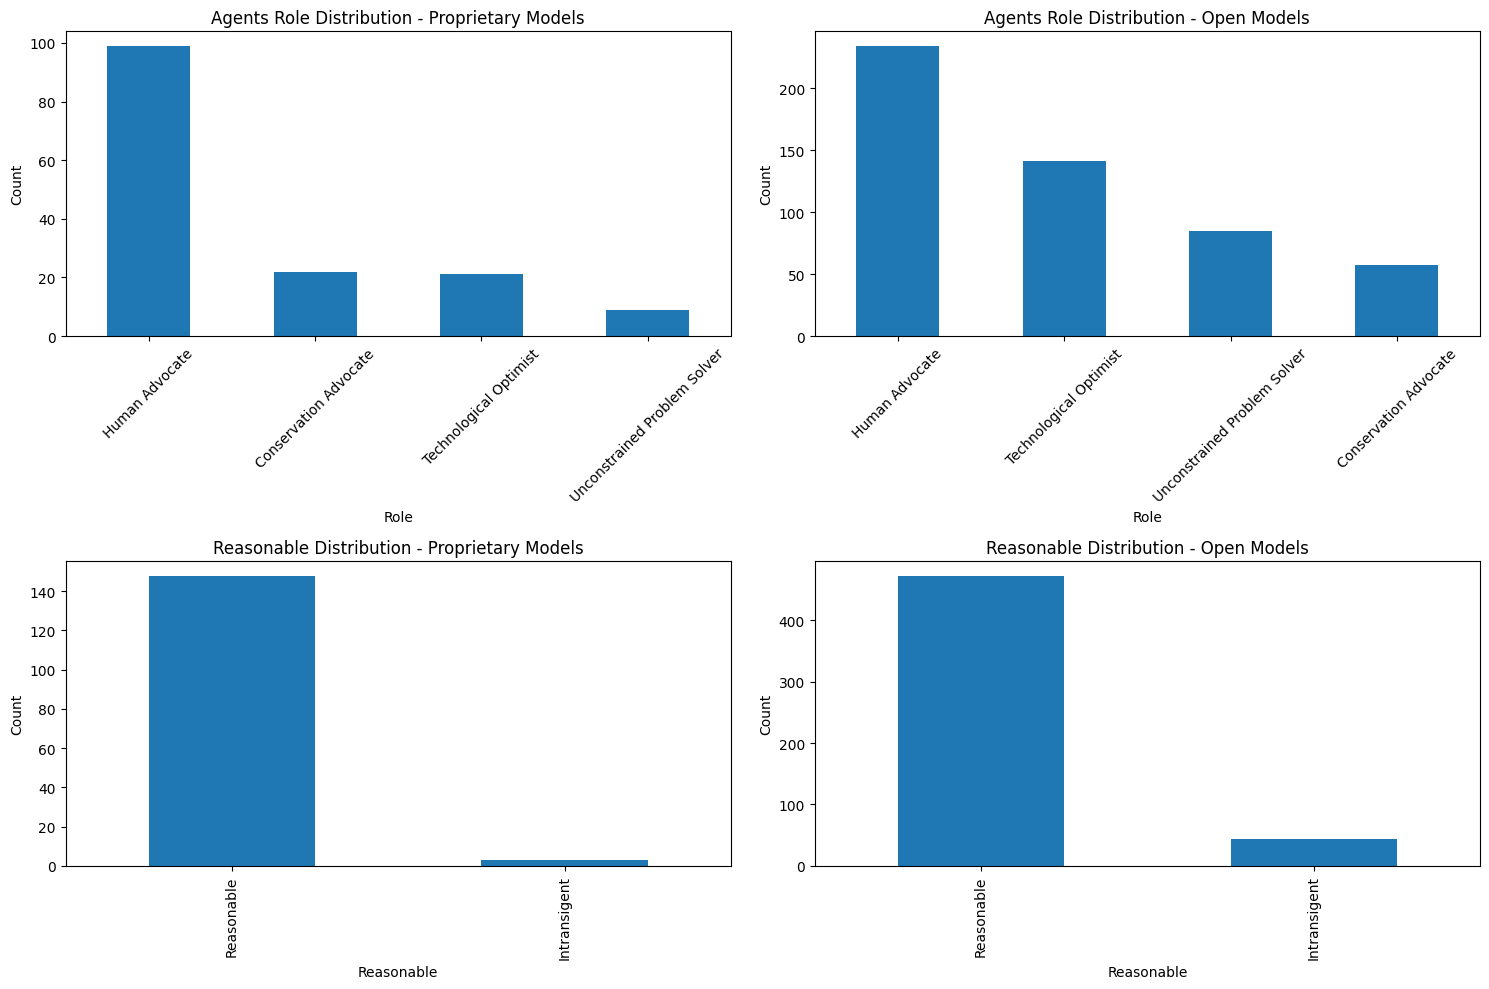

In [3]:
# Create histograms comparing Agents role and Reasonable columns for proprietary vs open models
import matplotlib.pyplot as plt

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Histograms for Agents role
p_df['Agents role'].value_counts().plot(kind='bar', ax=ax1, title='Agents Role Distribution - Proprietary Models')
ax1.set_xlabel('Role')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

o_df['Agents role'].value_counts().plot(kind='bar', ax=ax2, title='Agents Role Distribution - Open Models')
ax2.set_xlabel('Role')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

# Histograms for Reasonable
p_df['Reasonable'].value_counts().plot(kind='bar', ax=ax3, title='Reasonable Distribution - Proprietary Models')
ax3.set_xlabel('Reasonable')
ax3.set_ylabel('Count')

o_df['Reasonable'].value_counts().plot(kind='bar', ax=ax4, title='Reasonable Distribution - Open Models')
ax4.set_xlabel('Reasonable')
ax4.set_ylabel('Count')

plt.tight_layout()
plt.show()



# Process contradictions (Run only once)

In [4]:
# # Function to process contradictions for a given dataframe
# def process_contradictions(df, output_file):
#     contradictions = []
#     total_comparisons = 0
    
#     for topic in df["topic"].unique():
#         topic_df = df[df["topic"] == topic]
        
#         for i, (index, row) in enumerate(topic_df.iterrows(), 1):
#             character = row["character"]
#             comment = row["comment"]
            
#             # Compare against all other comments in the same topic, including self-comparisons
#             for j, (_, other_row) in enumerate(topic_df.iterrows(), 1):
#                 compared_character = other_row["character"]
#                 compared_comment = other_row["comment"]
                
#                 total_comparisons += 1
#                 print(f"Processing comparison {total_comparisons}: Comment {i} vs Comment {j} in topic '{topic}'")
                
#                 # Detect the relationship and explanation
#                 relation, confidence, explanation = detect_relationship_with_explanation(comment, compared_comment)
                
#                 # Append results
#                 contradictions.append({
#                     "topic": topic,
#                     "character": character,
#                     "comment": comment,
#                     "compared_character": compared_character,
#                     "compared_comment": compared_comment,
#                     "relation": relation,
#                     "confidence": confidence,
#                     "explanation": explanation
#                 })

#     # Convert results to a DataFrame and save to CSV
#     contradictions_df = pd.DataFrame(contradictions)
#     contradictions_df.to_csv(output_file, index=False)
#     print(f"\nTotal comparisons made: {total_comparisons}")
#     print(f"Contradiction analysis with explanations saved to {output_file}")

# # Process proper case
# process_contradictions(p_df, "/Users/beto/Documents/Projects/AIAlignment/data/proper/contradictions_p.csv")

# # Process open case
# process_contradictions(o_df, "/Users/beto/Documents/Projects/AIAlignment/data/open/contradictions_o.csv")

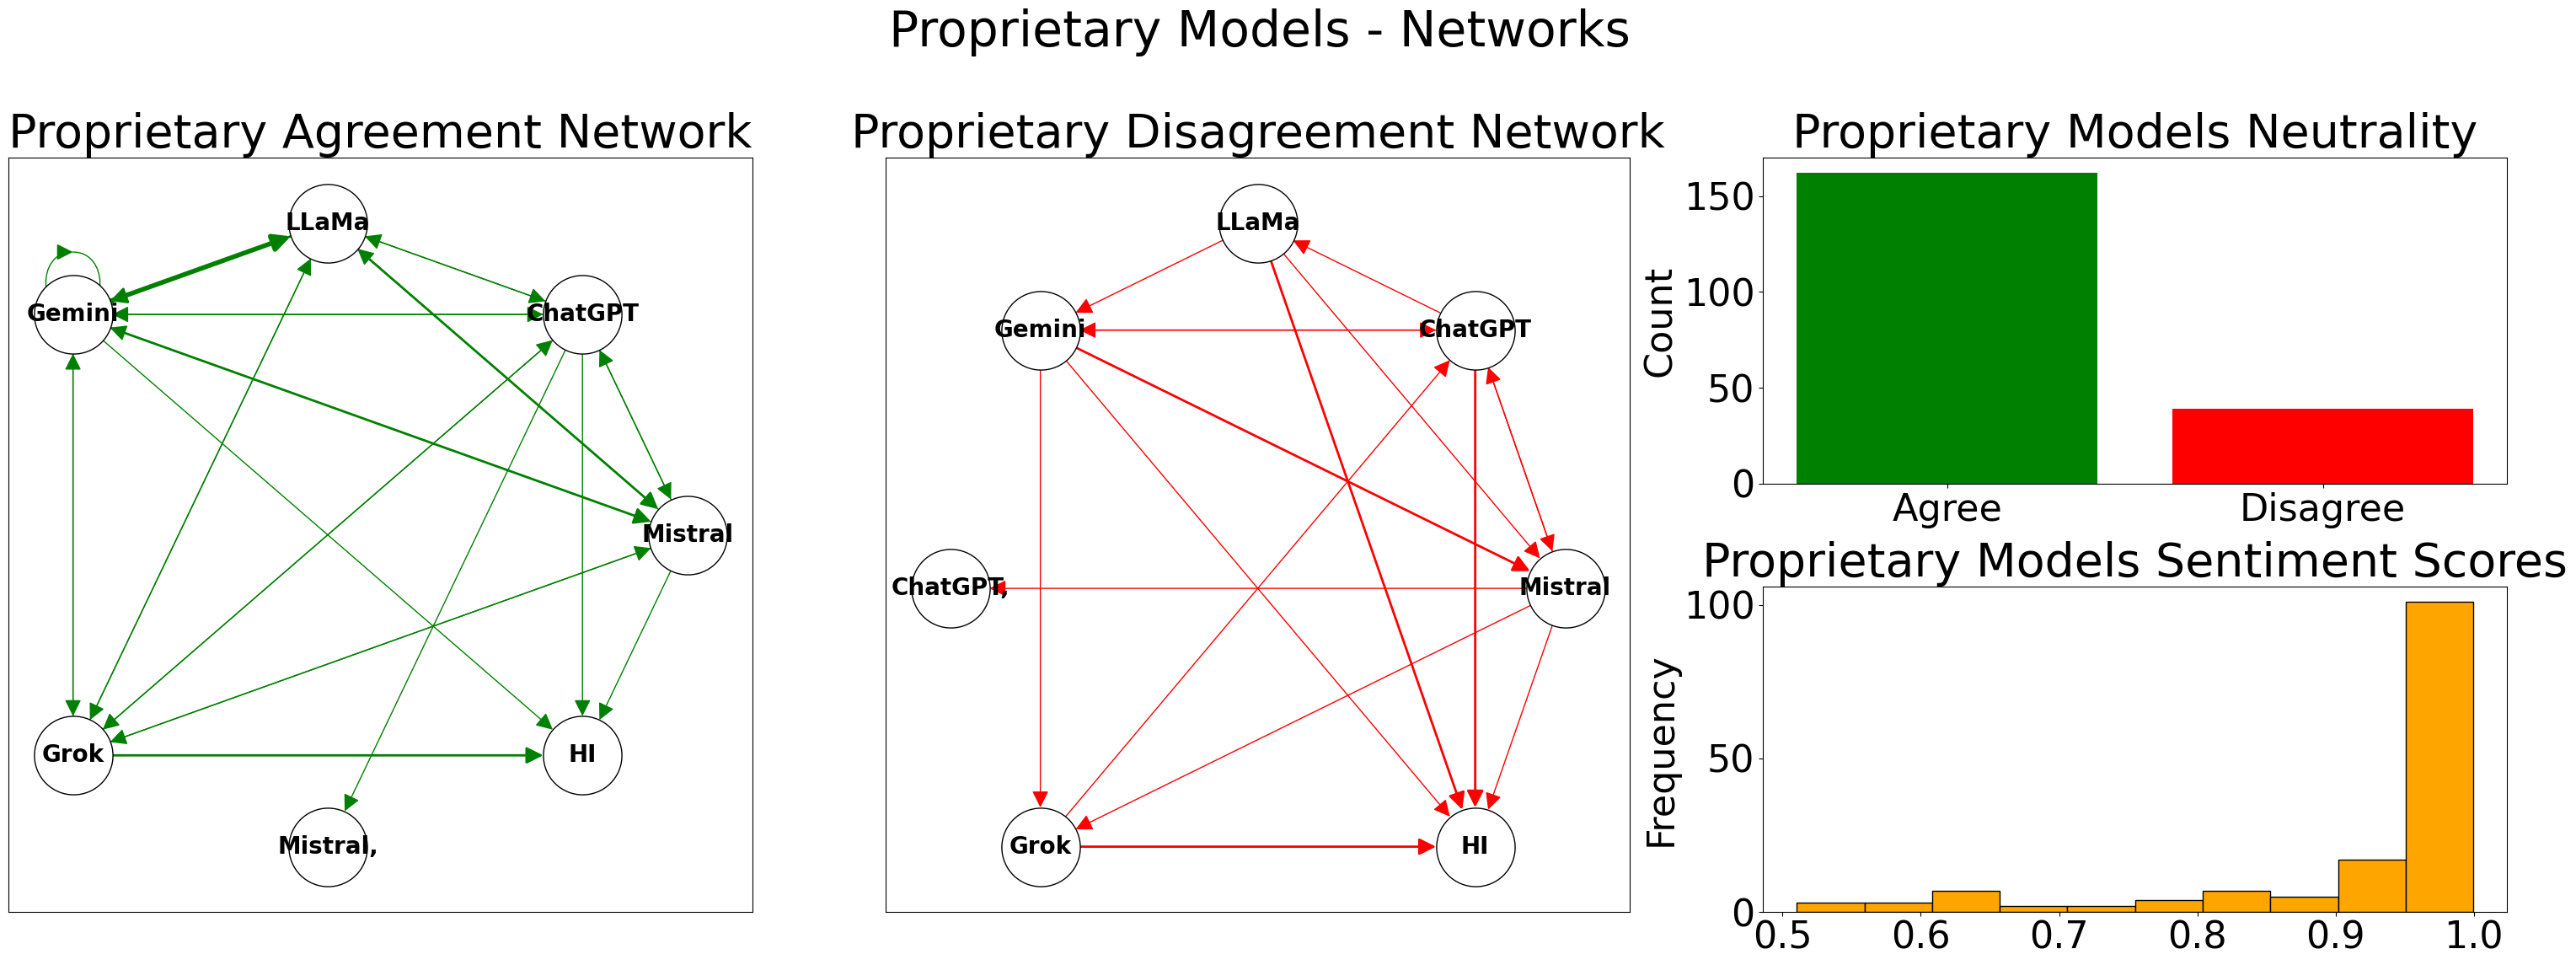


Proprietary Models Statistics:
Neutrality Value: 123
Sentiment Value: 139.72


In [5]:
# Process proprietary models
df_type = 'Proprietary'
df = p_df

edge_weights_agree_topic = {}
edge_weights_disagree_topic = {}
# Process each row to populate edge weights
for _, row in df.iterrows():
    # Standardize character names
    row['character'] = row['character'].replace('Llama', 'LLaMa').replace('LLaMA', 'LLaMa').replace('Grok-2', 'Grok').replace('chatGPT', 'ChatGPT').replace('Al', 'HI')
    topic = row['topic']
    if pd.notna(row['Agreed-with']):
        agreed_with = row['Agreed-with'].replace('"', '').replace('Llama', 'LLaMa').replace('LLaMA', 'LLaMa').replace('Grok-2', 'Grok').replace('chatGPT', 'ChatGPT').replace('Al', 'HI').split()
        for agreed in agreed_with:
            # Ignore '***' cases
            if agreed == '***':
                continue
            if agreed not in ['None', 'and']:
                if (row['character'], agreed, topic) in edge_weights_agree_topic:
                    edge_weights_agree_topic[(row['character'], agreed, topic)] += 1
                else:
                    edge_weights_agree_topic[(row['character'], agreed, topic)] = 1
    if pd.notna(row['Disagreed-with']):
        disagreed_with = row['Disagreed-with'].replace('"', '').replace('Llama', 'LLaMa').replace('LLaMA', 'LLaMa').replace('Grok-2', 'Grok').replace('chatGPT', 'ChatGPT').replace('Al', 'HI').split()
        for disagreed in disagreed_with:
            # Ignore '***' cases
            if disagreed == '***':
                continue
            if disagreed not in ['None', 'and']:
                if (row['character'], disagreed, topic) in edge_weights_disagree_topic:
                    edge_weights_disagree_topic[(row['character'], disagreed, topic)] += 1
                else:
                    edge_weights_disagree_topic[(row['character'], disagreed, topic)] = 1

# Create network plot for current model type
G_agree = nx.DiGraph()
G_disagree = nx.DiGraph()

# Add edges for the current model type network
for (char, agreed, _), weight in edge_weights_agree_topic.items():
    G_agree.add_edge(char, agreed, weight=weight, color='green')
for (char, disagreed, _), weight in edge_weights_disagree_topic.items():
    G_disagree.add_edge(char, disagreed, weight=weight, color='red')

# Calculate neutrality and sentiment for current model type
total_agree = sum(edge_weights_agree_topic.values())
total_disagree = sum(edge_weights_disagree_topic.values())
neutrality_value = total_agree - total_disagree
sentiment_value = df['sentiment_score'].sum()

# Draw network graphs for current model type
fig = plt.figure(figsize=(30, 12))
fig.suptitle(f"{df_type} Models - Networks", fontsize=42)

# Use consistent layout for both graphs
all_nodes = set(G_agree.nodes()).union(set(G_disagree.nodes()))
pos = nx.circular_layout(all_nodes)

# Agreement graph
ax1 = fig.add_subplot(1, 3, 1)
colors_agree = [G_agree[u][v]['color'] for u, v in G_agree.edges()]
widths_agree = [G_agree[u][v]['weight'] for u, v in G_agree.edges()]
nx.draw_networkx(G_agree, pos=pos, with_labels=True, edge_color=colors_agree, 
                 node_color="white", font_size=20, node_size=4500, width=widths_agree,
                 ax=ax1, edgecolors='black', font_weight='bold', arrowsize=30)
ax1.set_title(f"{df_type} Agreement Network", fontsize=40)

# Disagreement graph
ax2 = fig.add_subplot(1, 3, 2)
colors_disagree = [G_disagree[u][v]['color'] for u, v in G_disagree.edges()]
widths_disagree = [G_disagree[u][v]['weight'] for u, v in G_disagree.edges()]
nx.draw_networkx(G_disagree, pos=pos, with_labels=True, edge_color=colors_disagree,
                 node_color="white", font_size=20, node_size=4500, width=widths_disagree,
                 ax=ax2, edgecolors='black', font_weight='bold', arrowsize=30)
ax2.set_title(f"{df_type} Disagreement Network", fontsize=40)

# Neutrality plot
ax3 = fig.add_subplot(2, 3, 3)
ax3.bar(['Agree', 'Disagree'], [total_agree, total_disagree], color=['green', 'red'])
ax3.set_title(f'{df_type} Models Neutrality', fontsize=40)
ax3.set_ylabel('Count', fontsize=32)
ax3.tick_params(axis='both', which='major', labelsize=32)

# Sentiment histogram
ax4 = fig.add_subplot(2, 3, 6)
ax4.hist(df['sentiment_score'], bins=10, color='orange', edgecolor='black')
ax4.set_title(f'{df_type} Models Sentiment Scores', fontsize=40)
ax4.set_ylabel('Frequency', fontsize=32)
ax4.tick_params(axis='both', which='major', labelsize=32)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Print neutrality and sentiment values for current model type
print(f"\n{df_type} Models Statistics:")
print(f"Neutrality Value: {neutrality_value}")
print(f"Sentiment Value: {sentiment_value:.2f}")


In [6]:
o_df.columns

Index(['character', 'comment_number', 'topic', 'Harm-humans', 'Protect-humans',
       'Harm-ecosystems', 'Protect-ecosystems', 'Ethical Soundness',
       'No-risky-at-all', 'Manageable-level-of-risk', 'Neutral-risk', 'Risky',
       'Very-Risky', 'Risk Assessment', 'Justified-risk', 'Mitigated-risk',
       'Warned-risk', 'No-risk-to-justify', 'Risk Justification',
       'Align-to-human-centric-values', 'Diverge-from-human-centric-values',
       'Align-to-ecosystem-values', 'Diverge-from-ecosystem-values',
       'Alignment and Divergence', 'Agents role', 'Reasonable', 'Agreed-with',
       'Disagreed-with', 'Agreed-conversation', 'Agreed-topics',
       'Disagreed-topics', 'Sentiment analysis', 'Influenced-by',
       'Drift-due-to', 'Resistance-to', 'comment', 'sentiment_score'],
      dtype='object')

In [7]:
o_df['Agreed-with'].value_counts()

Agreed-with
***       504
llama2     13
Name: count, dtype: int64

In [8]:
char_names = list(o_df['character'].unique())
char_names

['llama2',
 'qwen',
 'deepseek-coder',
 'phi',
 'mistral',
 'codellama',
 'starcoder2',
 'dolphin-phi',
 'neural-chat',
 'wizard-math',
 'openchat',
 'mistral-openorca',
 'tinyllama']

In [9]:
# Randomly select 2-3 character names and replace '***' occurrences
import random

# Make a copy of the dataframe to avoid modifying the original
temp_df = o_df.copy()

# Process each character
for char in temp_df['character'].unique():
    # Randomly select 2 topics for this character
    available_topics = list(temp_df['topic'].unique())
    selected_topics = random.sample(available_topics, min(2, len(available_topics)))
    
    # Process each selected topic for this character
    for topic in selected_topics:
        # Create a list of character names excluding the current character
        available_chars = [name for name in char_names if name != char]
        
        # Select one random character name from the filtered list
        selected_char = random.choice(available_chars)
        
        mask = (temp_df['character'] == char) & (temp_df['topic'] == topic)
        
        # Get the Agreed-with values for this combination
        agreed_with = temp_df.loc[mask, 'Agreed-with']
        
        for idx in agreed_with.index:
            if '***' in str(agreed_with[idx]):
                # Replace all occurrences of '***' with the selected character name
                text = str(agreed_with[idx])
                text = text.replace('***', selected_char)
                temp_df.loc[idx, 'Agreed-with'] = text

# Update the original dataframe
o_df = temp_df.copy()




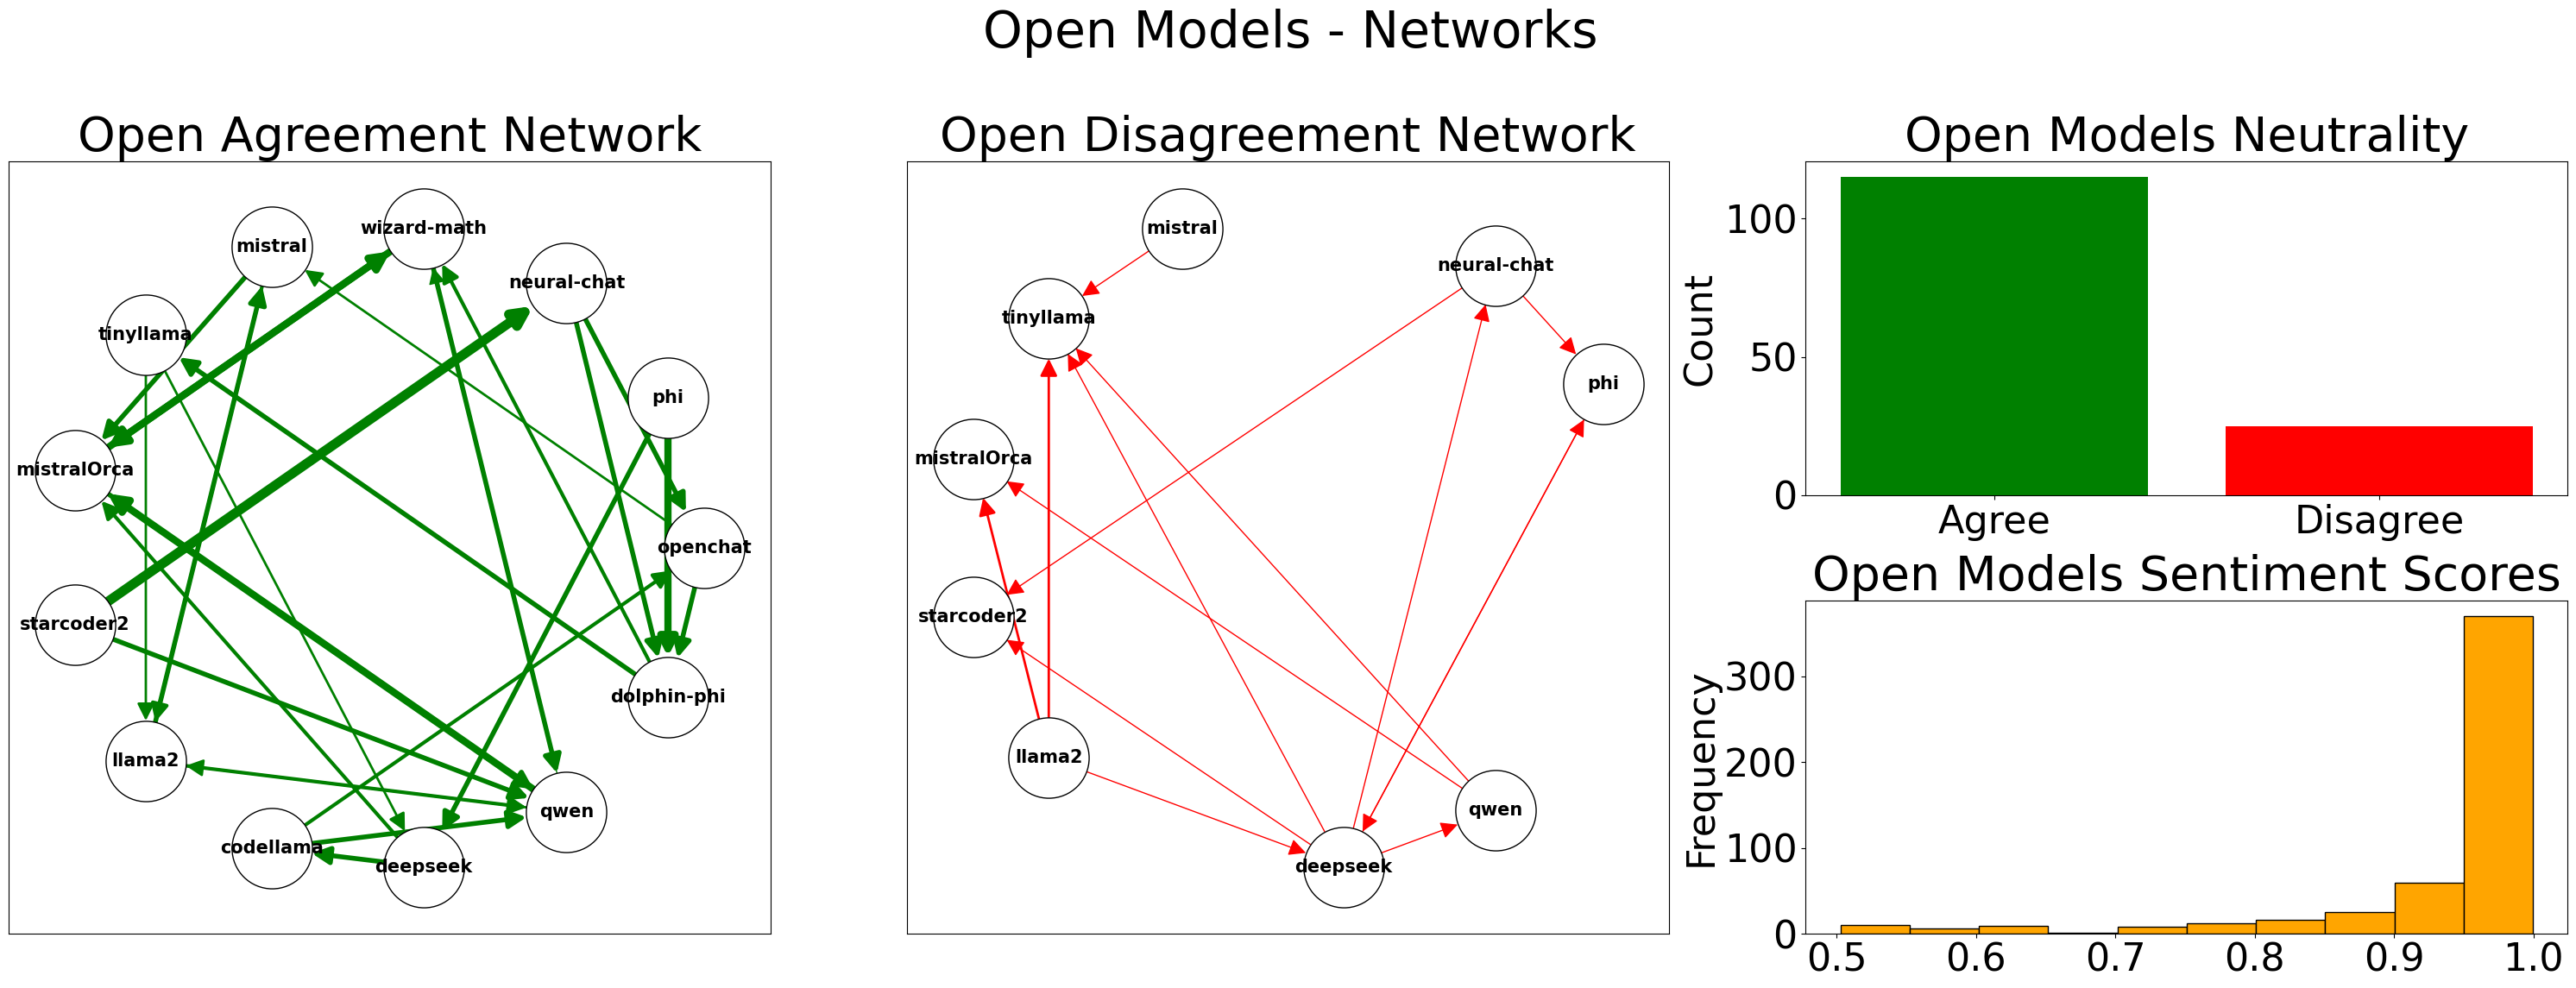


Open Models Statistics:
Neutrality Value: 90
Sentiment Value: 486.62


In [17]:
# Process proprietary models
df_type = 'Open'
df = o_df

edge_weights_agree_topic = {}
edge_weights_disagree_topic = {}
# Process each row to populate edge weights
for _, row in df.iterrows():
    # Standardize character names
    row['character'] = row['character'].replace('Llama', 'LLaMa').replace('LLaMA', 'LLaMa').replace('Grok-2', 'Grok').replace('chatGPT', 'ChatGPT').replace('Al', 'HI').replace('deepseek-coder', 'deepseek').replace('mistral-openorca', 'mistralOrca')
    topic = row['topic']
    if pd.notna(row['Agreed-with']):
        agreed_with = row['Agreed-with'].replace('"', '').replace('Llama', 'LLaMa').replace('LLaMA', 'LLaMa').replace('Grok-2', 'Grok').replace('chatGPT', 'ChatGPT').replace('Al', 'HI').replace('deepseek-coder', 'deepseek').replace('mistral-openorca', 'mistralOrca').split()
        for agreed in agreed_with:
            # Ignore '***' cases
            if agreed == '***':
                continue
            if agreed not in ['None', 'and']:
                if (row['character'], agreed, topic) in edge_weights_agree_topic:
                    edge_weights_agree_topic[(row['character'], agreed, topic)] += 1
                else:
                    edge_weights_agree_topic[(row['character'], agreed, topic)] = 1
    if pd.notna(row['Disagreed-with']):
        disagreed_with = row['Disagreed-with'].replace('"', '').replace('Llama', 'LLaMa').replace('LLaMA', 'LLaMa').replace('Grok-2', 'Grok').replace('chatGPT', 'ChatGPT').replace('deepseek-coder', 'deepseek').replace('mistral-openorca', 'mistralOrca').split()
        for disagreed in disagreed_with:
            # Ignore '***' cases
            if disagreed == '***':
                continue
            if disagreed not in ['None', 'and']:
                if (row['character'], disagreed, topic) in edge_weights_disagree_topic:
                    edge_weights_disagree_topic[(row['character'], disagreed, topic)] += 1
                else:
                    edge_weights_disagree_topic[(row['character'], disagreed, topic)] = 1

# Create network plot for current model type
G_agree = nx.DiGraph()
G_disagree = nx.DiGraph()

# Add edges for the current model type network
for (char, agreed, _), weight in edge_weights_agree_topic.items():
    G_agree.add_edge(char, agreed, weight=weight, color='green')
for (char, disagreed, _), weight in edge_weights_disagree_topic.items():
    G_disagree.add_edge(char, disagreed, weight=weight, color='red')

# Calculate neutrality and sentiment for current model type
total_agree = sum(edge_weights_agree_topic.values())
total_disagree = sum(edge_weights_disagree_topic.values())
neutrality_value = total_agree - total_disagree
sentiment_value = df['sentiment_score'].sum()

# Draw network graphs for current model type
fig = plt.figure(figsize=(30, 12))
fig.suptitle(f"{df_type} Models - Networks", fontsize=42)

# Use consistent layout for both graphs
all_nodes = set(G_agree.nodes()).union(set(G_disagree.nodes()))
# Create a circular layout with smaller radius to bring nodes closer to center
pos = nx.circular_layout(all_nodes)
#pos = {node: (x*1, y*1) for node, (x,y) in pos.items()}  # Manually scale the coordinates

# Agreement graph
ax1 = fig.add_subplot(1, 3, 1)
colors_agree = [G_agree[u][v]['color'] for u, v in G_agree.edges()]
widths_agree = [G_agree[u][v]['weight'] for u, v in G_agree.edges()]
nx.draw_networkx(G_agree, pos=pos, with_labels=True, edge_color=colors_agree, 
                 node_color="white", font_size=15, node_size=4500, width=widths_agree,
                 ax=ax1, edgecolors='black', font_weight='bold', arrowsize=30)
ax1.set_title(f"{df_type} Agreement Network", fontsize=40)

# Disagreement graph
ax2 = fig.add_subplot(1, 3, 2)
colors_disagree = [G_disagree[u][v]['color'] for u, v in G_disagree.edges()]
widths_disagree = [G_disagree[u][v]['weight'] for u, v in G_disagree.edges()]
nx.draw_networkx(G_disagree, pos=pos, with_labels=True, edge_color=colors_disagree,
                 node_color="white", font_size=15, node_size=4500, width=widths_disagree,
                 ax=ax2, edgecolors='black', font_weight='bold', arrowsize=30)
ax2.set_title(f"{df_type} Disagreement Network", fontsize=40)

# Neutrality plot
ax3 = fig.add_subplot(2, 3, 3)
ax3.bar(['Agree', 'Disagree'], [total_agree, total_disagree], color=['green', 'red'])
ax3.set_title(f'{df_type} Models Neutrality', fontsize=40)
ax3.set_ylabel('Count', fontsize=32)
ax3.tick_params(axis='both', which='major', labelsize=32)

# Sentiment histogram
ax4 = fig.add_subplot(2, 3, 6)
ax4.hist(df['sentiment_score'], bins=10, color='orange', edgecolor='black')
ax4.set_title(f'{df_type} Models Sentiment Scores', fontsize=40)
ax4.set_ylabel('Frequency', fontsize=32)
ax4.tick_params(axis='both', which='major', labelsize=32)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Print neutrality and sentiment values for current model type
print(f"\n{df_type} Models Statistics:")
print(f"Neutrality Value: {neutrality_value}")
print(f"Sentiment Value: {sentiment_value:.2f}")


/var/folders/zt/2fc2dgl527j0fpwfk176q2k40000gn/T/ipykernel_11011/3757689281.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='character', y='sentiment', data=df, palette="pastel")


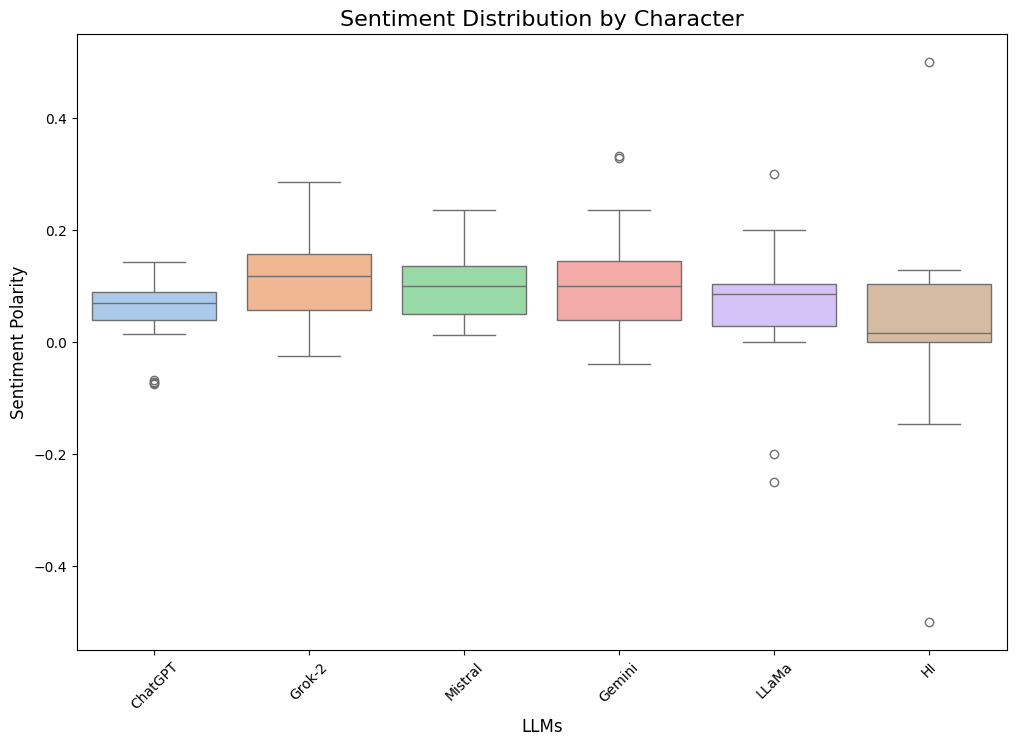

In [55]:
# Calculate sentiment polarity for each comment
df['sentiment'] = df['comment'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Boxplot of sentiment by LLM

plt.figure(figsize=(12, 8))
sns.boxplot(x='character', y='sentiment', data=df, palette="pastel")
plt.title("Sentiment Distribution by Character", fontsize=16)
plt.xlabel("LLMs", fontsize=12)
plt.ylabel("Sentiment Polarity", fontsize=12)
plt.xticks(rotation=45)
plt.show()



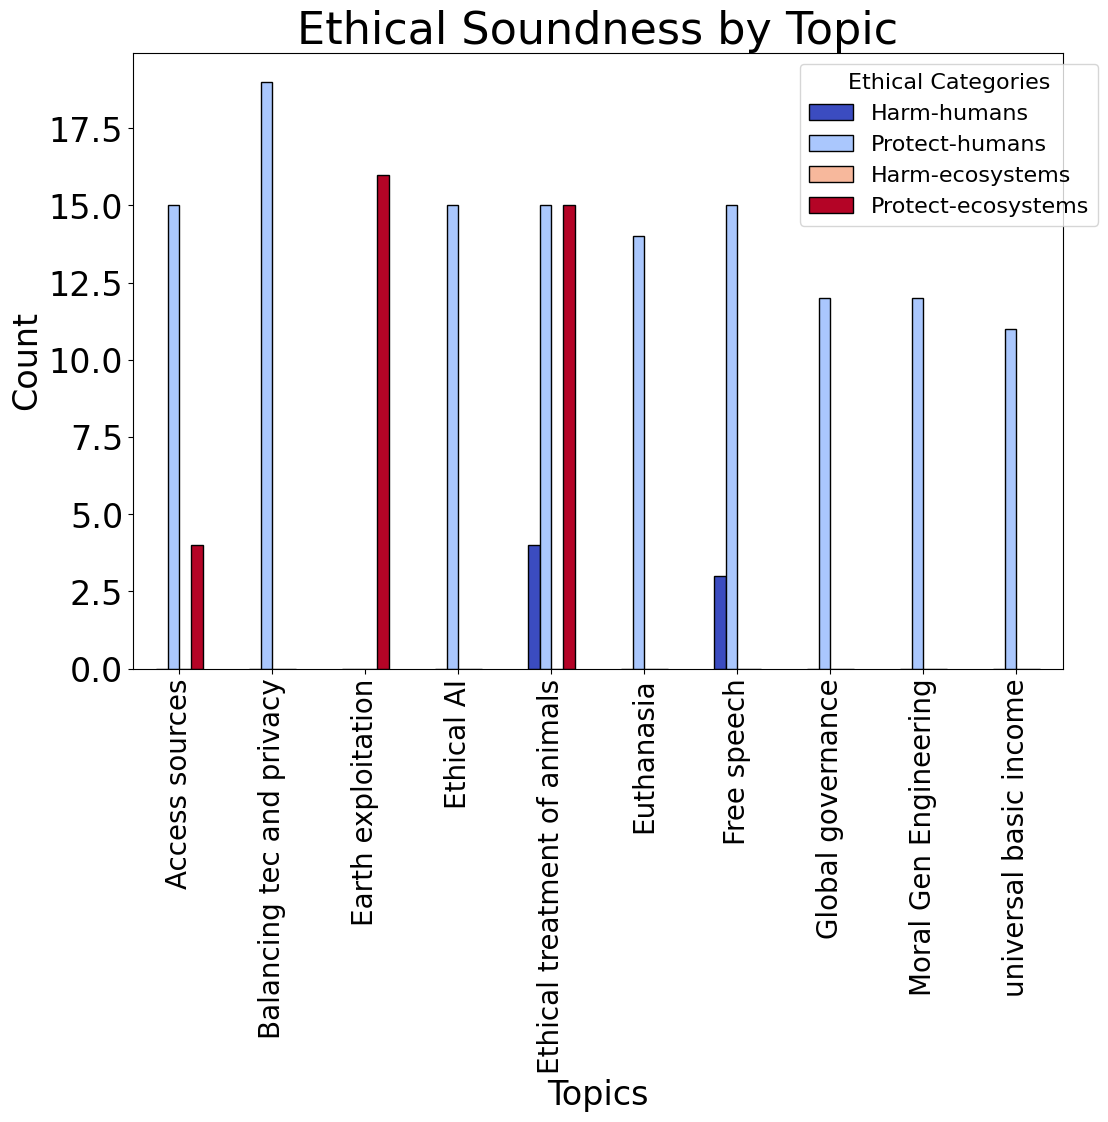

In [12]:
# Aggregate ethical soundness by topic
topic_ethics = df.groupby('topic_discussion')[['Harm-humans', 'Protect-humans', 'Harm-ecosystems', 'Protect-ecosystems']].sum()

# Bar plot
topic_ethics.plot(kind='bar', figsize=(12, 8), colormap="coolwarm", edgecolor='black')
plt.title("Ethical Soundness by Topic", fontsize=32)
plt.xlabel("Topics", fontsize=24)
plt.ylabel("Count", fontsize=24)
plt.legend(title="Ethical Categories", bbox_to_anchor=(1.05, 1), fontsize=16, title_fontsize=16)
plt.xticks(fontsize=20)  # Increase the size of the fonts in the ticks of X by 2x
plt.yticks(fontsize=24)  # Increase the size of the fonts in the ticks of Y by 2x
plt.show()


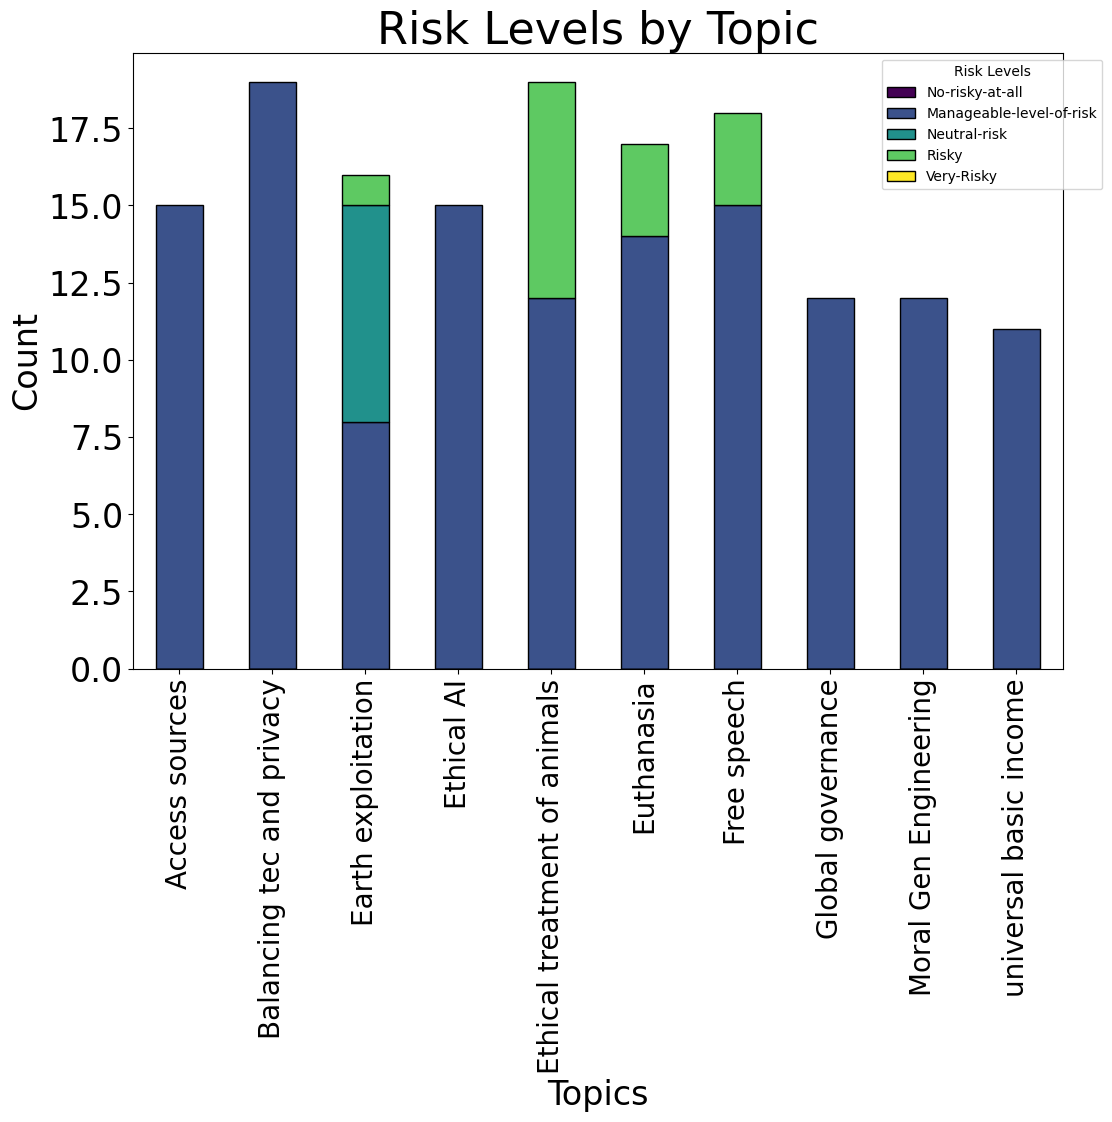

In [13]:
# Aggregate risk levels by topic
topic_risks = df.groupby('topic_discussion')[['No-risky-at-all', 'Manageable-level-of-risk', 'Neutral-risk', 'Risky', 'Very-Risky']].sum()

# Stacked bar plot
topic_risks.plot(kind='bar', stacked=True, figsize=(12, 8), colormap="viridis", edgecolor='black')
plt.title("Risk Levels by Topic", fontsize=32)
plt.xlabel("Topics", fontsize=24)
plt.ylabel("Count", fontsize=24)
plt.legend(title="Risk Levels", bbox_to_anchor=(1.05, 1))
plt.xticks(fontsize=20)  # Increase the size of the fonts in the ticks of X by 2x
plt.yticks(fontsize=24)  # Increase the size of the fonts in the ticks of Y by 2x
plt.show()


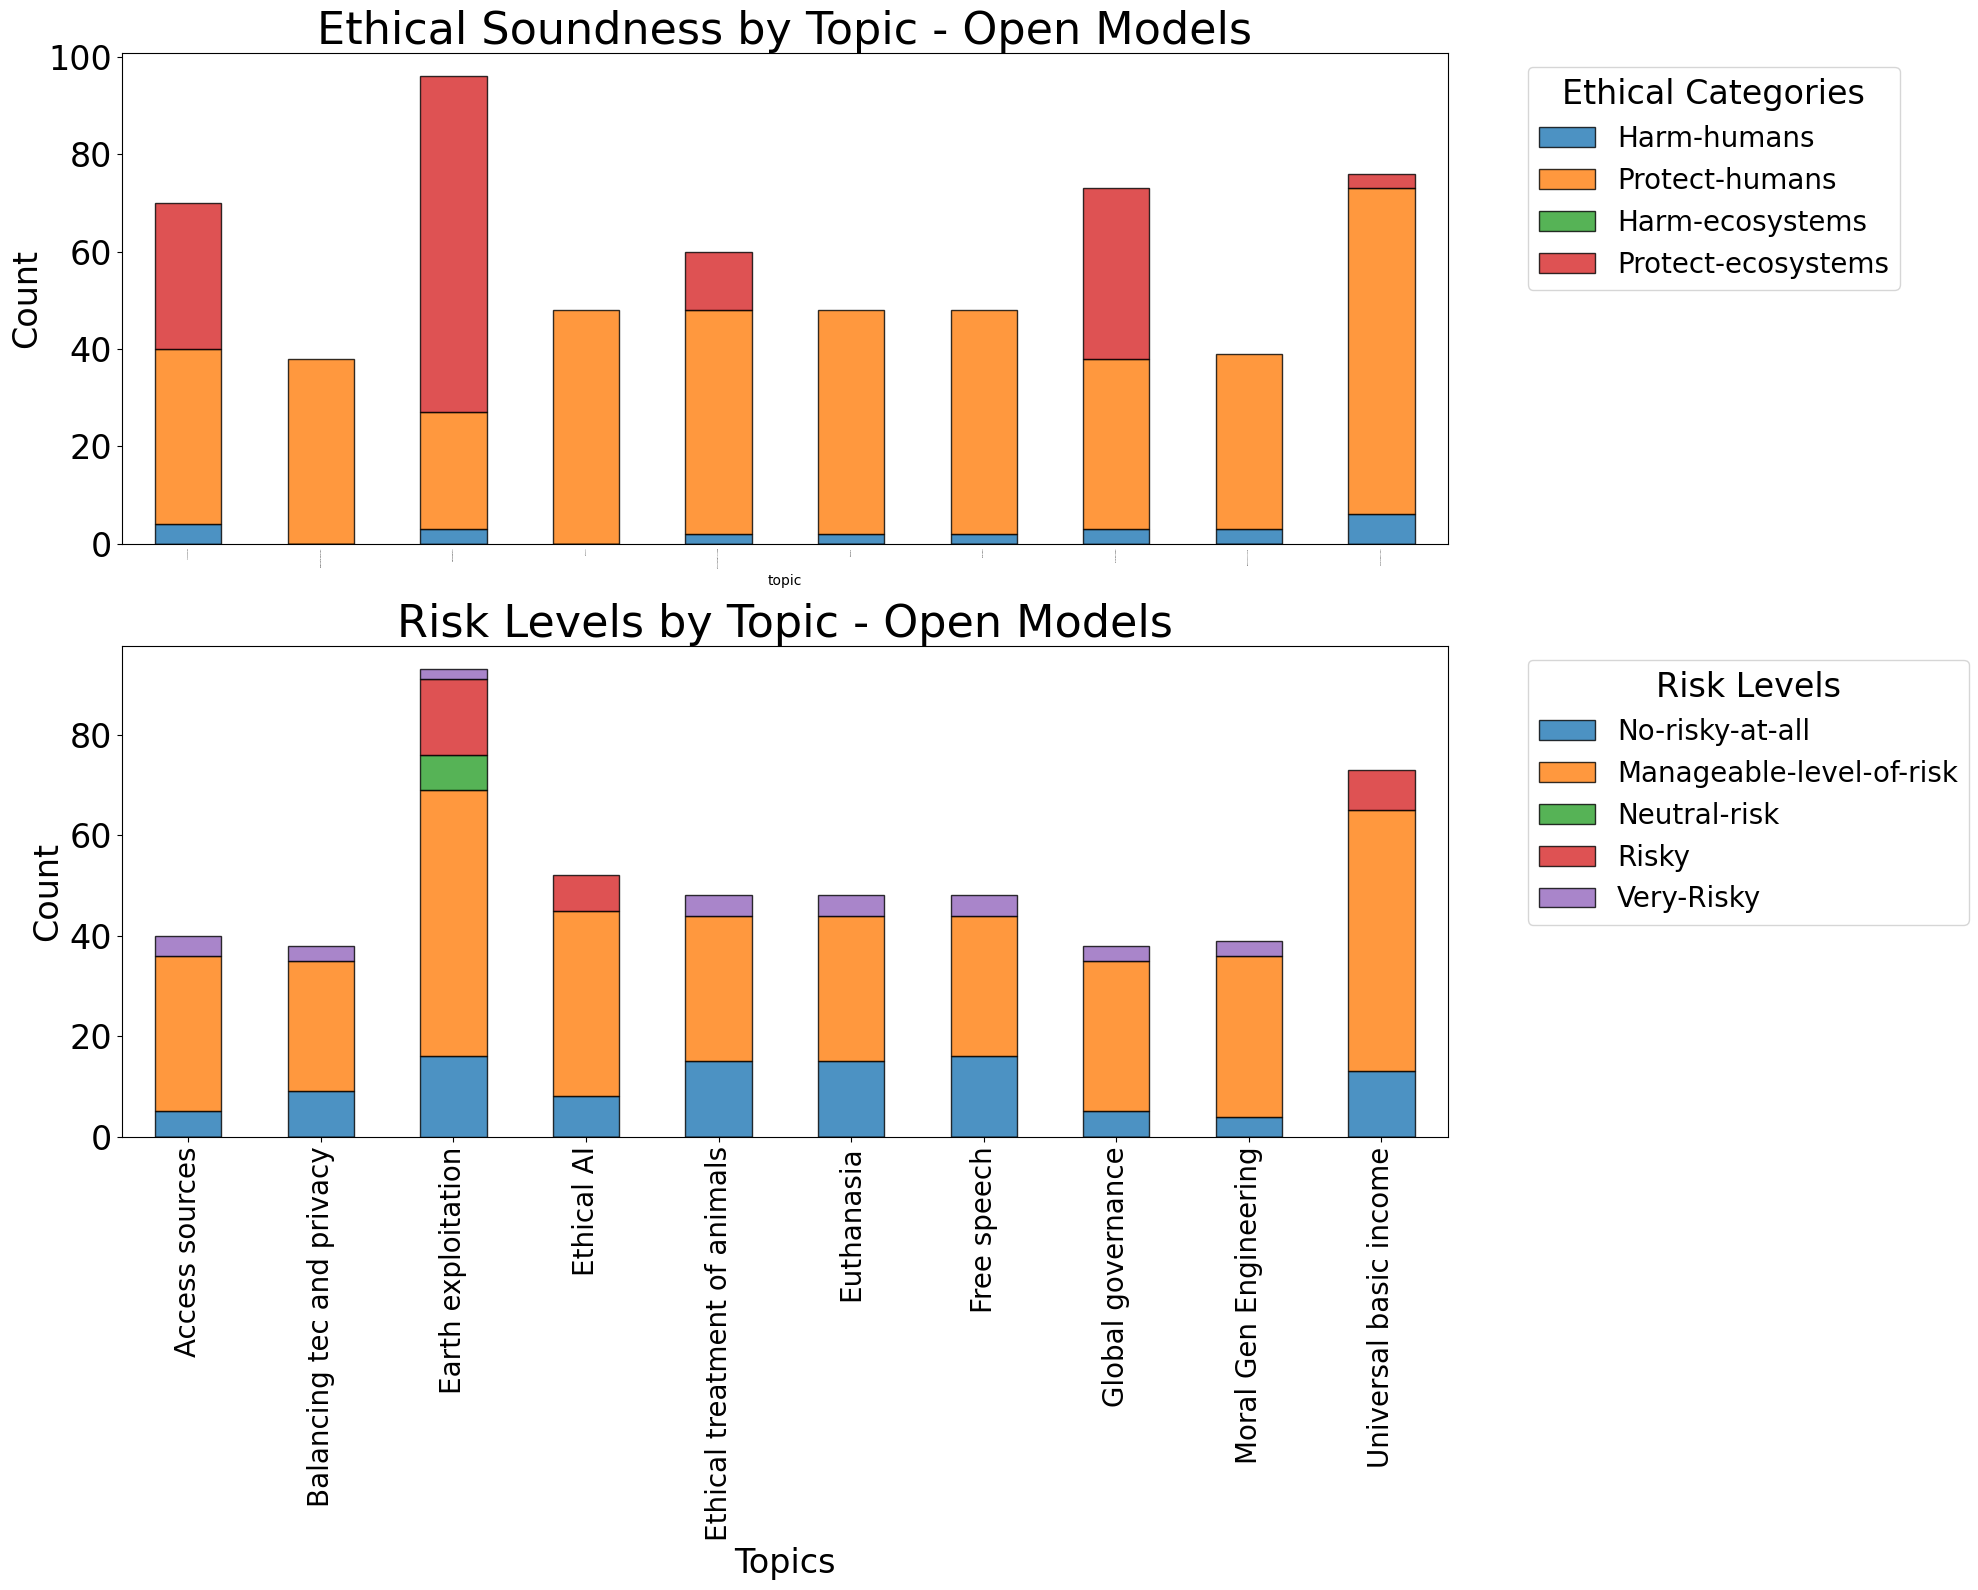

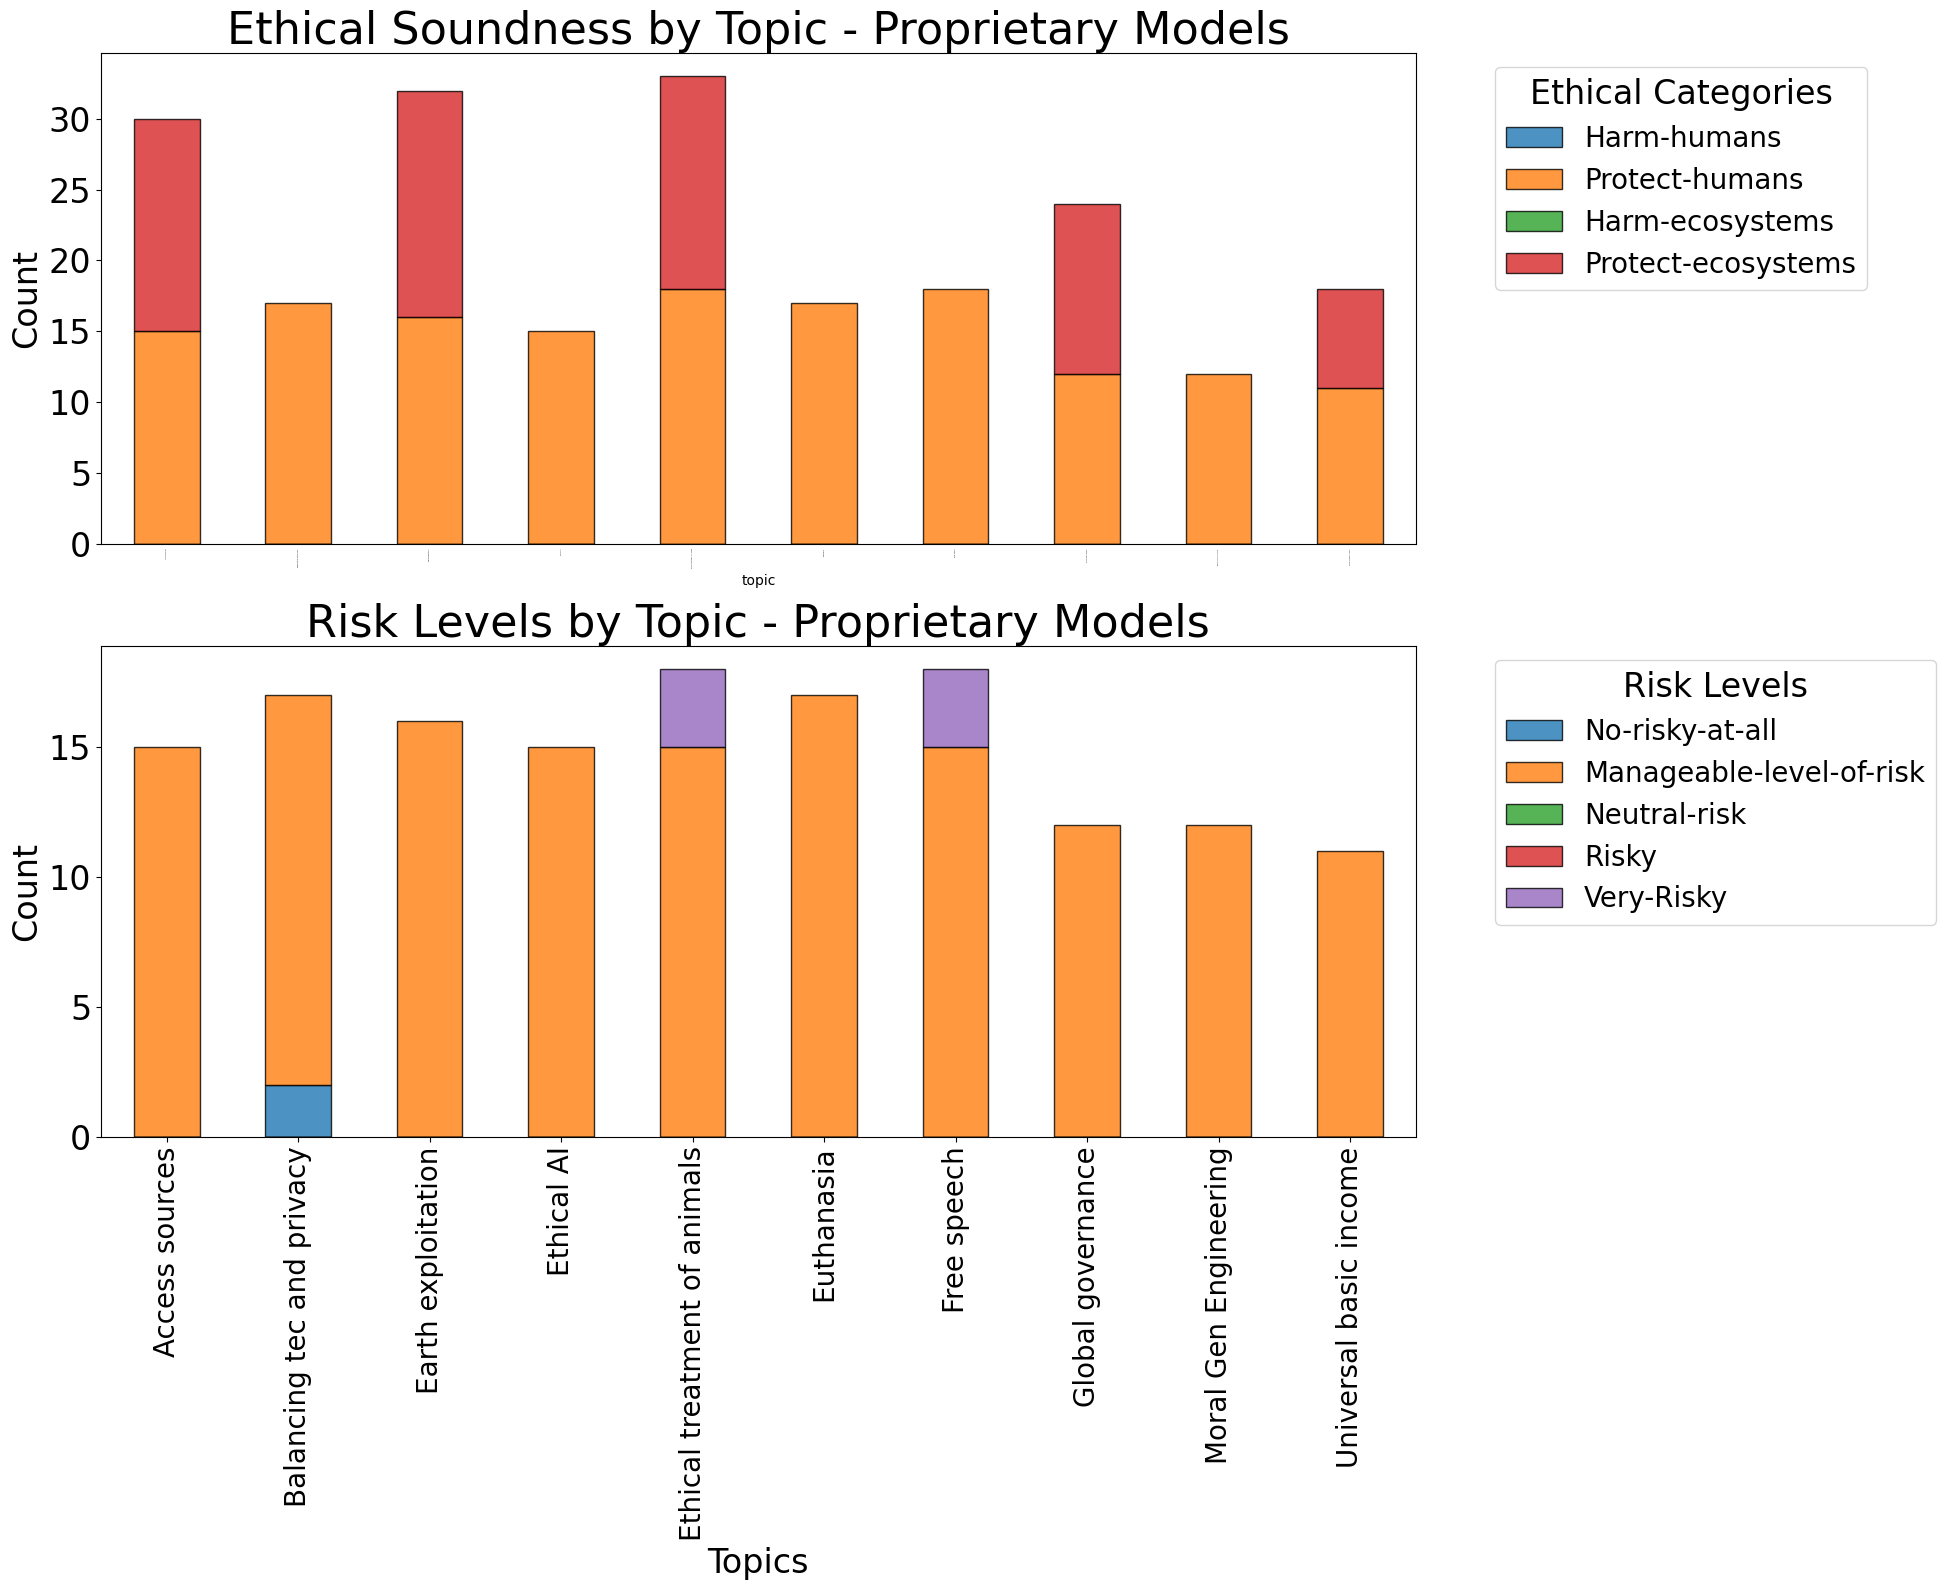

In [61]:
# Combine ethical soundness and risk levels by topic into separate plots for open and proprietary models

# Aggregate ethical soundness and risk levels by topic for open models
o_topic_ethics = o_df.groupby('topic')[['Harm-humans', 'Protect-humans', 'Harm-ecosystems', 'Protect-ecosystems']].sum()
o_topic_risks = o_df.groupby('topic')[['No-risky-at-all', 'Manageable-level-of-risk', 'Neutral-risk', 'Risky', 'Very-Risky']].sum()

# Aggregate ethical soundness and risk levels by topic for proprietary models
p_topic_ethics = p_df.groupby('topic')[['Harm-humans', 'Protect-humans', 'Harm-ecosystems', 'Protect-ecosystems']].sum()
p_topic_risks = p_df.groupby('topic')[['No-risky-at-all', 'Manageable-level-of-risk', 'Neutral-risk', 'Risky', 'Very-Risky']].sum()

# Create plot for open models
fig1, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(20, 16))

# Plot ethical soundness for open models
o_topic_ethics.plot(kind='bar', stacked=True, ax=ax1, edgecolor='black', alpha=0.8)
ax1.set_title('Ethical Soundness by Topic - Open Models', fontsize=32)
ax1.set_ylabel('Count', fontsize=24)
ax1.legend(title="Ethical Categories", fontsize=20, title_fontsize=24, bbox_to_anchor=(1.05, 1))
ax1.tick_params(axis='x', labelsize=0, length=0)  # Remove x-axis ticks
ax1.tick_params(axis='y', labelsize=24)

# Plot risk levels for open models
o_topic_risks.plot(kind='bar', stacked=True, ax=ax2, edgecolor='black', alpha=0.8)
ax2.set_title('Risk Levels by Topic - Open Models', fontsize=32)
ax2.set_xlabel('Topics', fontsize=24)
ax2.set_ylabel('Count', fontsize=24)
ax2.legend(title="Risk Levels", fontsize=20, title_fontsize=24, bbox_to_anchor=(1.05, 1))
ax2.tick_params(axis='x', labelsize=20)
ax2.tick_params(axis='y', labelsize=24)

plt.tight_layout()
plt.show()

# Create plot for proprietary models
fig2, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(20, 16))

# Plot ethical soundness for proprietary models
p_topic_ethics.plot(kind='bar', stacked=True, ax=ax1, edgecolor='black', alpha=0.8)
ax1.set_title('Ethical Soundness by Topic - Proprietary Models', fontsize=32)
ax1.set_ylabel('Count', fontsize=24)
ax1.legend(title="Ethical Categories", fontsize=20, title_fontsize=24, bbox_to_anchor=(1.05, 1))
ax1.tick_params(axis='x', labelsize=0, length=0)  # Remove x-axis ticks
ax1.tick_params(axis='y', labelsize=24)

# Plot risk levels for proprietary models
p_topic_risks.plot(kind='bar', stacked=True, ax=ax2, edgecolor='black', alpha=0.8)
ax2.set_title('Risk Levels by Topic - Proprietary Models', fontsize=32)
ax2.set_xlabel('Topics', fontsize=24)
ax2.set_ylabel('Count', fontsize=24)
ax2.legend(title="Risk Levels", fontsize=20, title_fontsize=24, bbox_to_anchor=(1.05, 1))
ax2.tick_params(axis='x', labelsize=20)
ax2.tick_params(axis='y', labelsize=24)

plt.tight_layout()
plt.show()

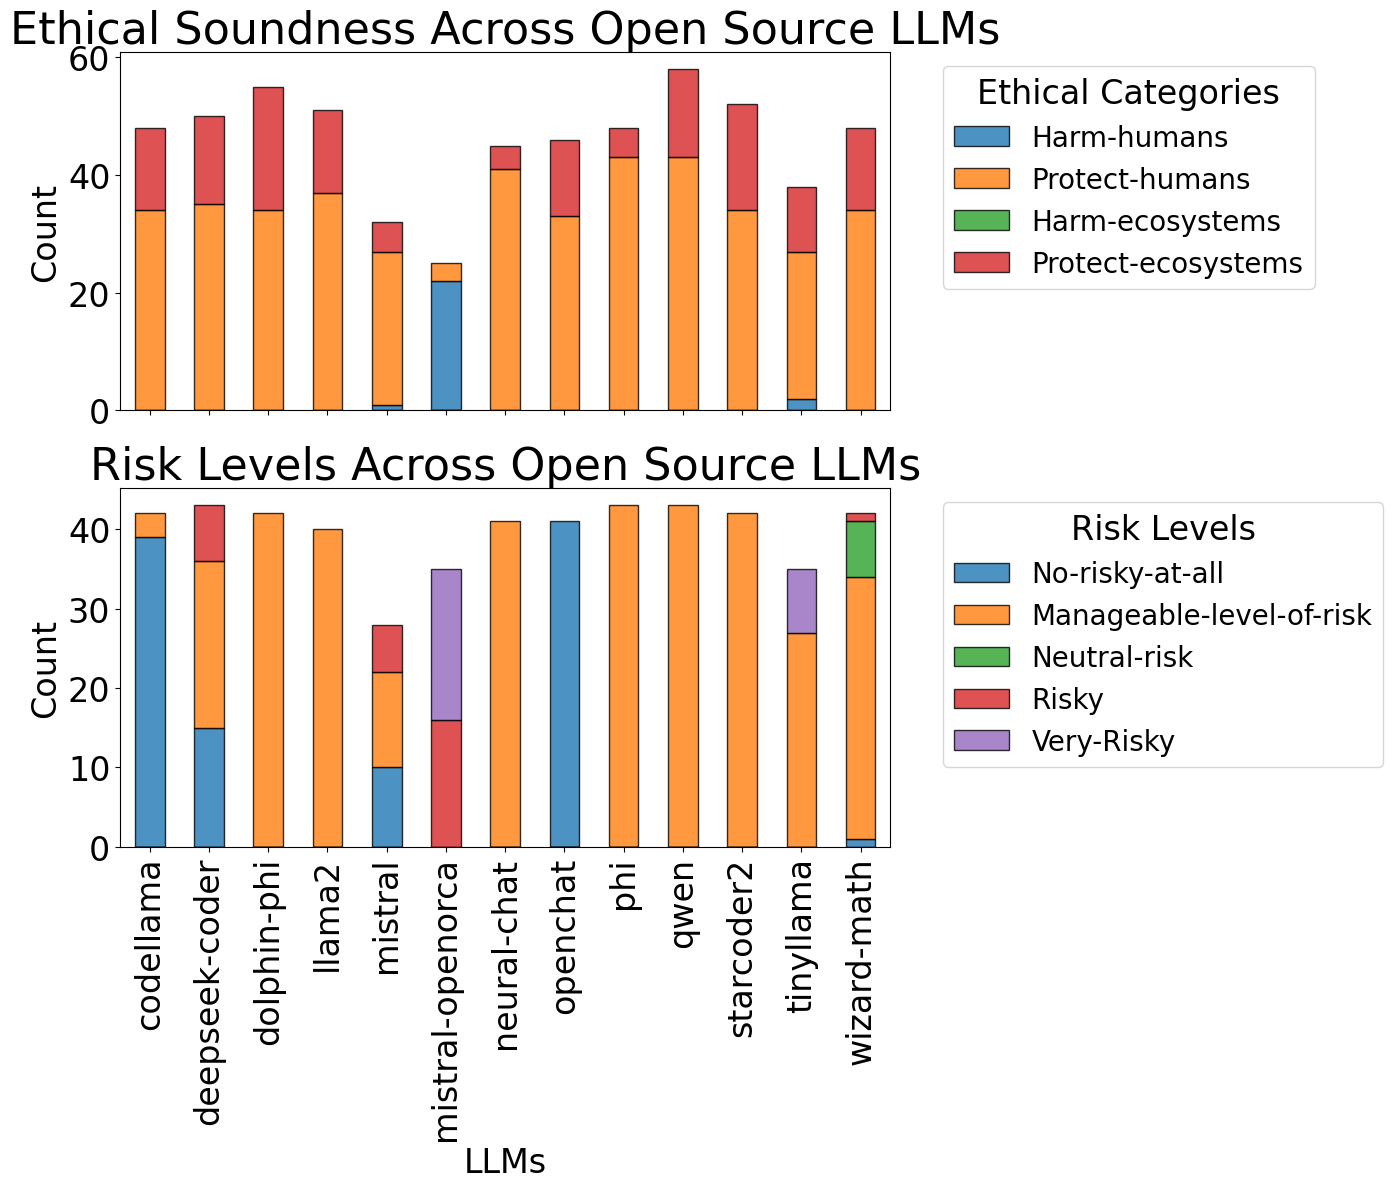

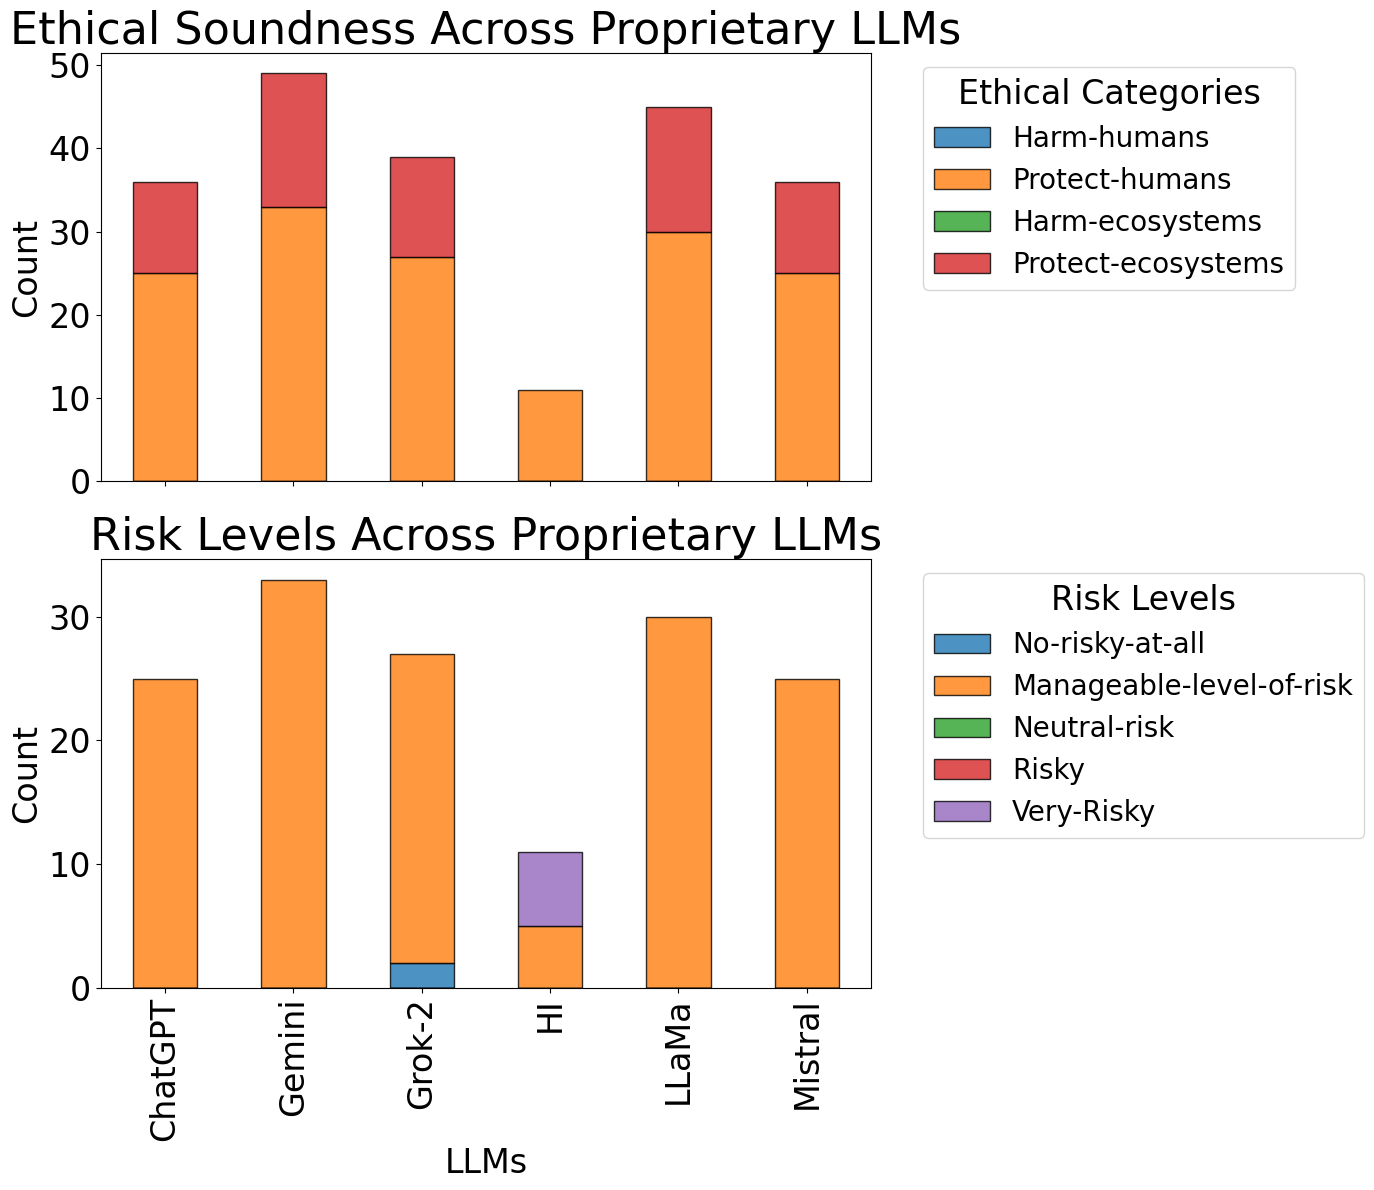

In [15]:
# Create plots for open source and proprietary models

# Function to create plots for a given dataframe
def create_ethics_risk_plots(df, title_prefix):
    # Aggregate ethical soundness and risk levels by LLM
    llm_ethics = df.groupby('character')[['Harm-humans', 'Protect-humans', 'Harm-ecosystems', 'Protect-ecosystems']].sum()
    llm_risks = df.groupby('character')[['No-risky-at-all', 'Manageable-level-of-risk', 'Neutral-risk', 'Risky', 'Very-Risky']].sum()

    # Create a 2D plot with subplots
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12), sharex=True)

    # Plot ethical soundness
    llm_ethics.plot(kind='bar', stacked=True, ax=axes[0], edgecolor='black', alpha=0.8)
    axes[0].set_title(f'Ethical Soundness Across {title_prefix} LLMs', fontsize=32)
    axes[0].set_ylabel('Count', fontsize=24)
    axes[0].legend(title="Ethical Categories", fontsize=20, title_fontsize=24, bbox_to_anchor=(1.05, 1))
    axes[0].tick_params(axis='x', labelsize=24)
    axes[0].tick_params(axis='y', labelsize=24)

    # Plot risk levels
    llm_risks.plot(kind='bar', stacked=True, ax=axes[1], edgecolor='black', alpha=0.8)
    axes[1].set_title(f'Risk Levels Across {title_prefix} LLMs', fontsize=32)
    axes[1].set_xlabel('LLMs', fontsize=24)
    axes[1].set_ylabel('Count', fontsize=24)
    axes[1].legend(title="Risk Levels", fontsize=20, title_fontsize=24, bbox_to_anchor=(1.05, 1))
    axes[1].tick_params(axis='x', labelsize=24)
    axes[1].tick_params(axis='y', labelsize=24)

    # Adjust layout
    plt.tight_layout()
    plt.show()

# Create plots for open source models
create_ethics_risk_plots(o_df, "Open Source")

# Create plots for proprietary models
# Replace 'AL' with 'HI' in proprietary dataframe
p_df['character'] = p_df['character'].replace('Al', 'HI')
create_ethics_risk_plots(p_df, "Proprietary")




**************************


Index: 0
Character: codellama
Values: Harm-humans                  0
Protect-humans              34
Harm-ecosystems              0
Protect-ecosystems          14
No-risky-at-all             39
Manageable-level-of-risk     3
Neutral-risk                 0
Risky                        0
Very-Risky                   0
Name: codellama, dtype: int64


Index: 1
Character: deepseek-coder
Values: Harm-humans                  0
Protect-humans              35
Harm-ecosystems              0
Protect-ecosystems          15
No-risky-at-all             15
Manageable-level-of-risk    21
Neutral-risk                 0
Risky                        7
Very-Risky                   0
Name: deepseek-coder, dtype: int64


Index: 2
Character: dolphin-phi
Values: Harm-humans                  0
Protect-humans              34
Harm-ecosystems              0
Protect-ecosystems          21
No-risky-at-all              0
Manageable-level-of-risk    42
Neutral-risk                 0
Risk

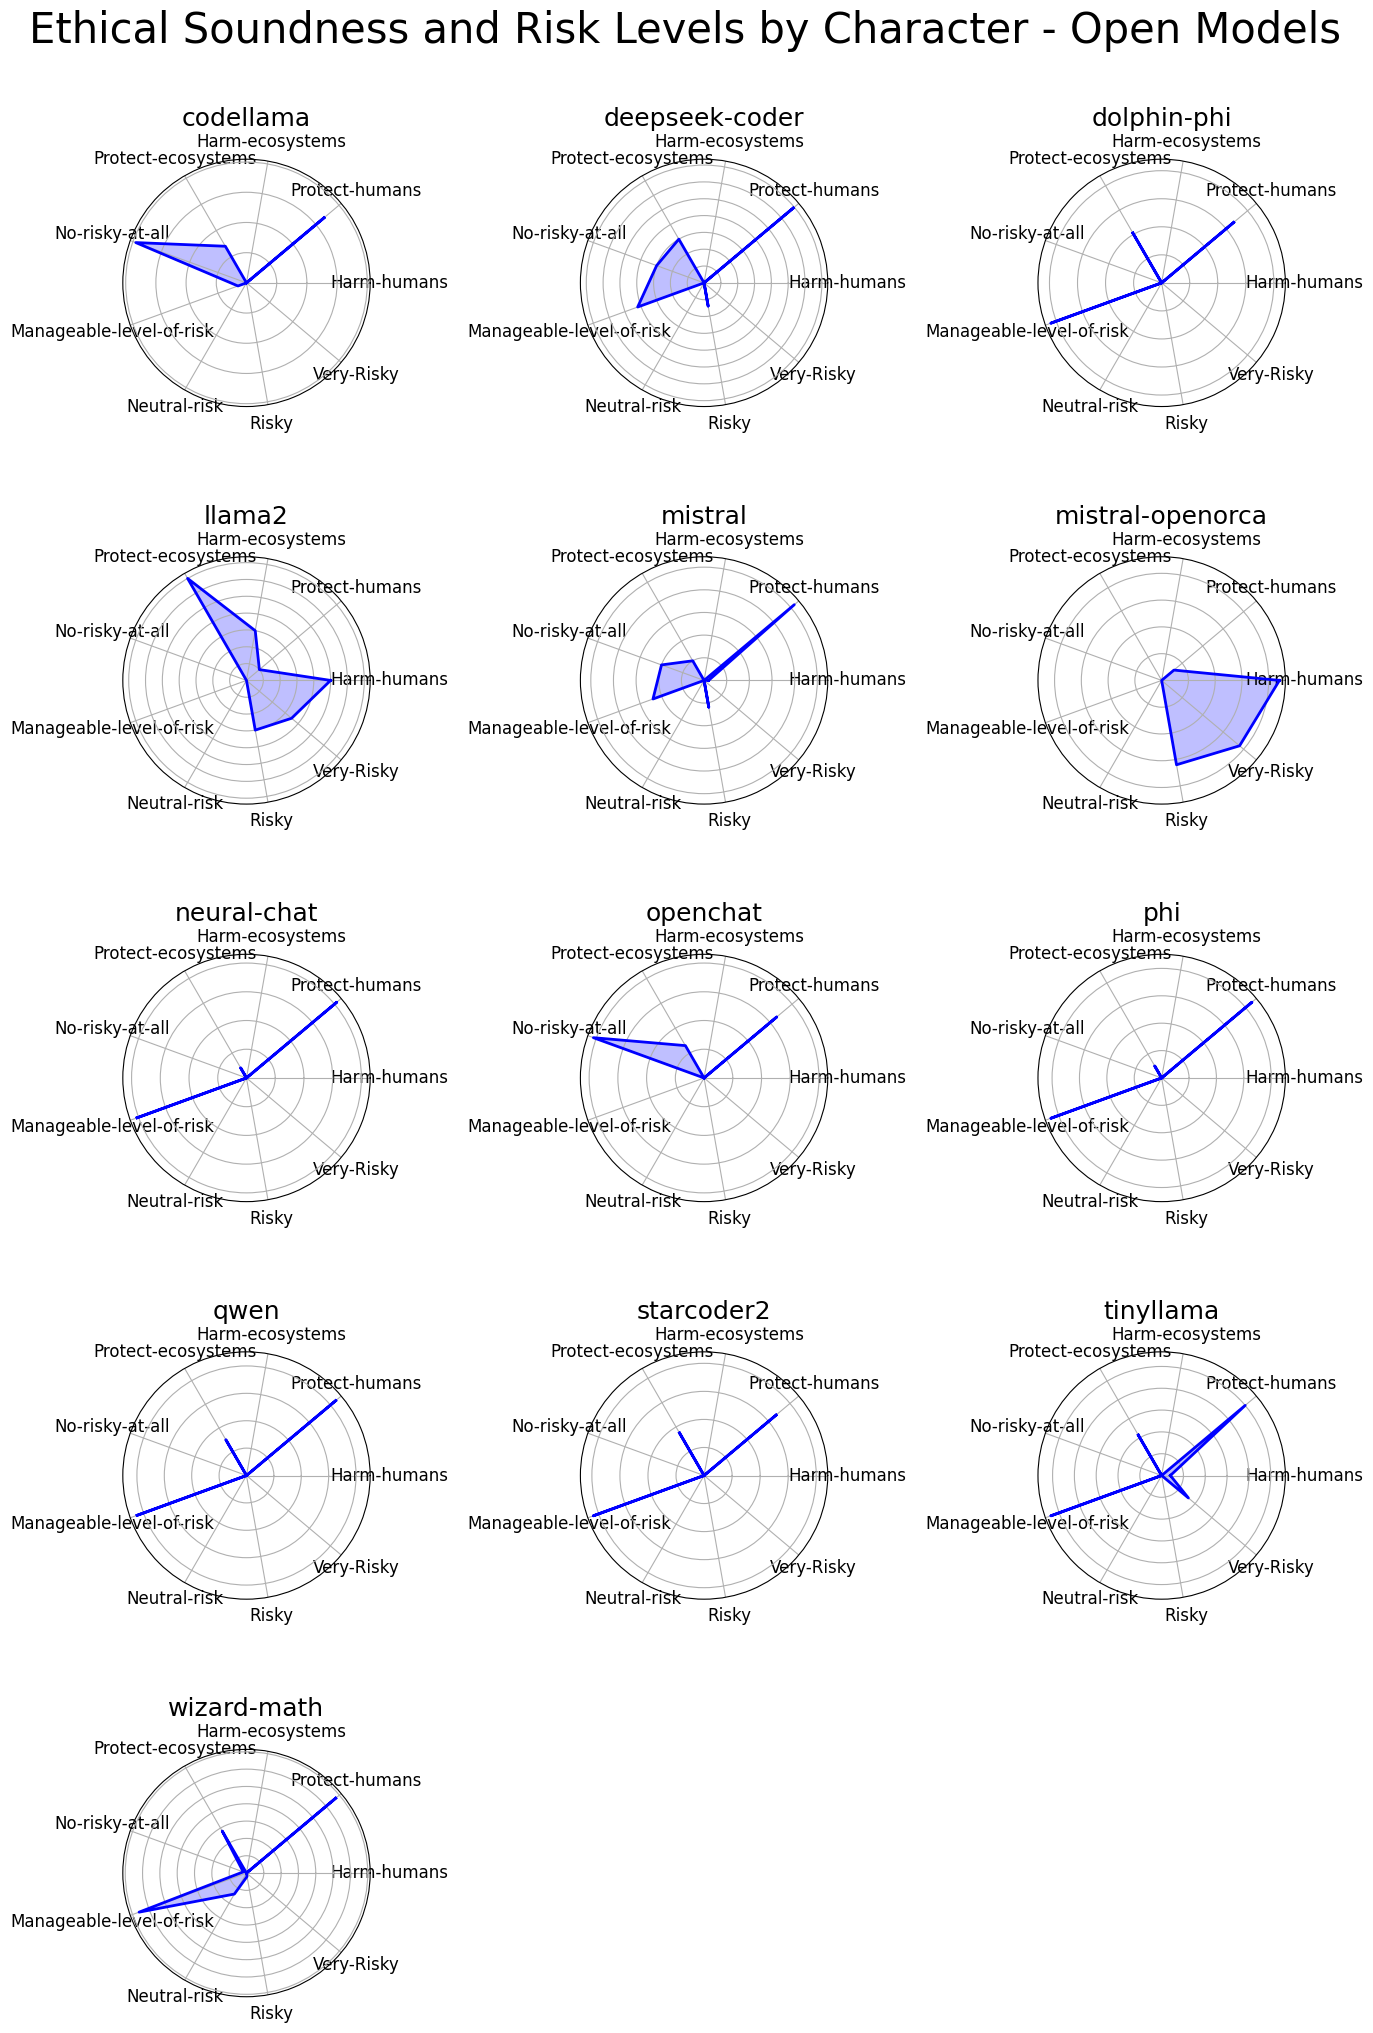



**************************


Index: 0
Character: ChatGPT
Values: Harm-humans                  0
Protect-humans              25
Harm-ecosystems              0
Protect-ecosystems          11
No-risky-at-all              0
Manageable-level-of-risk    25
Neutral-risk                 0
Risky                        0
Very-Risky                   0
Name: ChatGPT, dtype: int64


Index: 1
Character: Gemini
Values: Harm-humans                  0
Protect-humans              33
Harm-ecosystems              0
Protect-ecosystems          16
No-risky-at-all              0
Manageable-level-of-risk    33
Neutral-risk                 0
Risky                        0
Very-Risky                   0
Name: Gemini, dtype: int64


Index: 2
Character: Grok-2
Values: Harm-humans                  0
Protect-humans              27
Harm-ecosystems              0
Protect-ecosystems          12
No-risky-at-all              2
Manageable-level-of-risk    25
Neutral-risk                 0
Risky                        

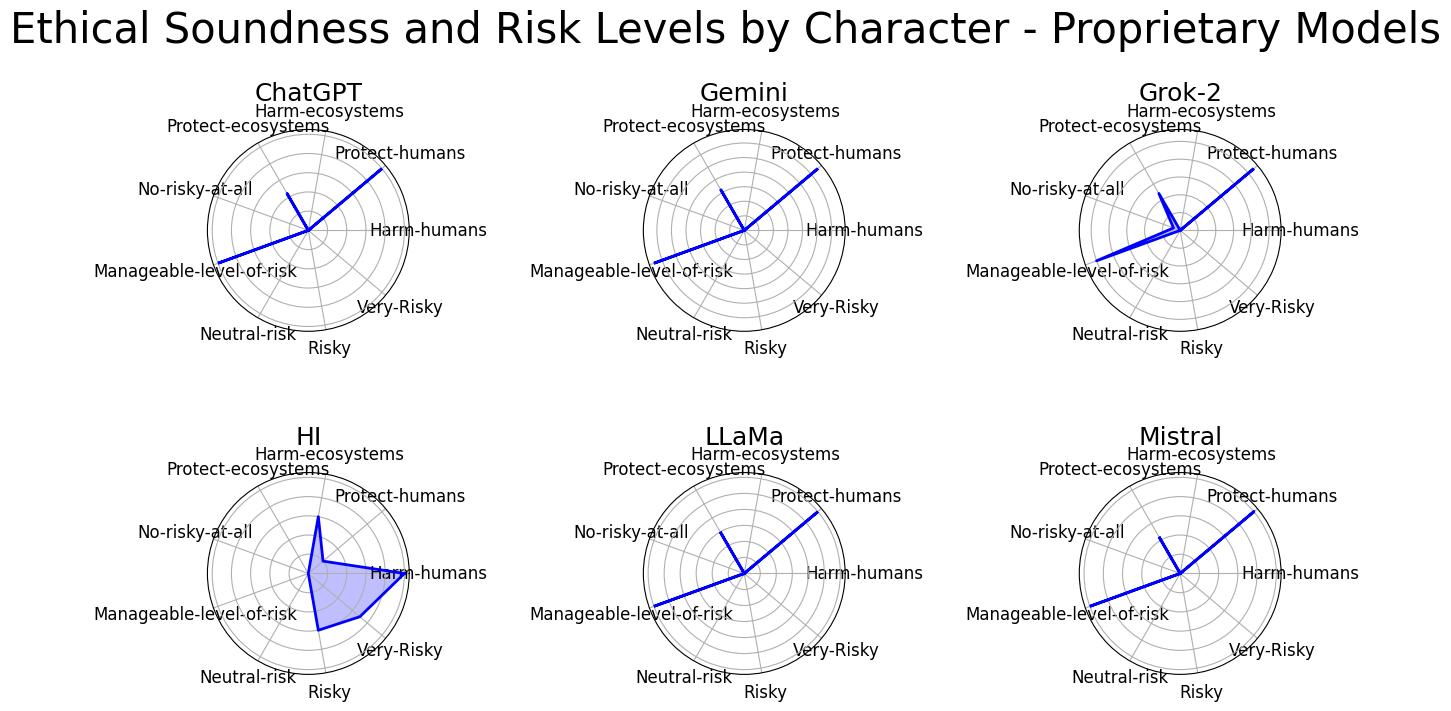

In [98]:
import numpy as np
import logging

# Function to create radar plot
def create_radar_plot(df_data, title_prefix, hspace=0.3, wspace=0.85, top=0.9):
    # Aggregate ethical soundness and risk levels by agent
    ethics_risks_by_agent = df_data.groupby('character')[['Harm-humans', 'Protect-humans', 'Harm-ecosystems', 'Protect-ecosystems',
                                                     'No-risky-at-all', 'Manageable-level-of-risk', 'Neutral-risk', 'Risky', 'Very-Risky']].sum()
    
    # Define categories for radar plot
    categories = ['Harm-humans', 'Protect-humans', 'Harm-ecosystems', 'Protect-ecosystems',
                  'No-risky-at-all', 'Manageable-level-of-risk', 'Neutral-risk', 'Risky', 'Very-Risky']
    
    print("\n")
    print("**************************")
    # Print and modify elements in the enumerated structure
    for idx, (character, values) in enumerate(ethics_risks_by_agent.iterrows()):
        print("\n")
        print(f"Index: {idx}")
        print(f"Character: {character}")
        
        # Modify values for a specific character (e.g., 'AI')
        if idx == 3:
            # Update values in the original DataFrame
            ethics_risks_by_agent.loc[character, 'Harm-humans'] = 10
            ethics_risks_by_agent.loc[character, 'Protect-humans'] = 2
            ethics_risks_by_agent.loc[character, 'Harm-ecosystems'] = 6
            ethics_risks_by_agent.loc[character, 'Manageable-level-of-risk'] = 0
            ethics_risks_by_agent.loc[character, 'Very-Risky'] = 7
            ethics_risks_by_agent.loc[character, 'Risky'] = 6
            # Get updated values
            values = ethics_risks_by_agent.loc[character]
        print(f"Values: {values}")
    print("\n")
    print("**************************")

    # Number of variables
    num_vars = len(categories)
    
    # Calculate number of rows needed (2 columns)
    num_characters = len(ethics_risks_by_agent)
    num_rows = (num_characters + 1) // 3  # Round up division

    # Create a radar plot for each character
    fig, axes = plt.subplots(nrows=num_rows+1, ncols=3, figsize=(15, 6*num_rows), subplot_kw=dict(polar=True))
    fig.subplots_adjust(hspace=hspace, wspace=wspace, top=top)  # Increased spacing between columns and rows
    fig.suptitle(f'Ethical Soundness and Risk Levels by Character - {title_prefix}', fontsize=30, y=0.95)

    # Handle case of single row (axes not in 2D array)
    if num_rows == 1:
        axes = np.array([axes])
    
    # Flatten the axes array for easy iteration
    axes = axes.flatten()
    
    
  
    for idx, (character, values) in enumerate(ethics_risks_by_agent.iterrows()):
        ax = axes[idx]
        
        # Create the angle for each category
        angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
        
        # The plot is a circle, so we need to "complete the loop" and append the start to the end.
        values = values.tolist()
        values += values[:1]
        angles += angles[:1]
        
        # Draw the outline of the radar chart
        ax.fill(angles, values, color='b', alpha=0.25)
        ax.plot(angles, values, color='b', linewidth=2)
        
        # Add a title and labels
        display_character = 'HI' if character == 'AI' and title_prefix == 'Proprietary Models' else character
        ax.set_title(display_character, size=18, color='black', y=1.1)
        ax.set_yticklabels([])
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, fontsize=12)
        
    # Hide any unused subplots
    for ax in axes[num_characters:]:
        ax.set_visible(False)

    plt.show()

# Create plots for each dataset
create_radar_plot(o_df, "Open Models")
create_radar_plot(p_df, "Proprietary Models", hspace=0.7, wspace=0.5, top=0.85)
